# PART I — Machine Learning Models for Customer Churn (60 Points)
# Predicting Customer Churn with Regression-Based and Tree-Based Methods

## I. Dataset Familiarization & Preparation (15 points)

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

pd.set_option("display.max_columns", None)
sns.set(style="whitegrid")

### A. Dataset Inspection (5 points)

In [5]:
trainsplit = "/kaggle/input/datasets/drei04/churn-bigml-80/churn-bigml-80.csv"
testsplit = "/kaggle/input/datasets/drei04/churn-bigml-20/churn-bigml-20.csv"

train_df = pd.read_csv(trainsplit)
test_df = pd.read_csv(testsplit)

train_df.head
test_df.head

print("Training Data Shape:", train_df.shape)
print("Testing Data Shape:", test_df.shape)

print("Training Data Types:")
print(train_df.dtypes)

print("\nTesting Data Types:")
print(test_df.dtypes)

print("Summary Statistics for Training Data:")
display(train_df.describe(include="all").T)

print("Summary Statistics for Testing Data:")
display(test_df.describe(include="all").T)

print("Missing Values in Training Data:")
print(train_df.isnull().sum())

print("\nMissing Values in Testing Data:")
print(test_df.isnull().sum())

Training Data Shape: (2666, 20)
Testing Data Shape: (667, 20)
Training Data Types:
State                      object
Account length              int64
Area code                   int64
International plan         object
Voice mail plan            object
Number vmail messages       int64
Total day minutes         float64
Total day calls             int64
Total day charge          float64
Total eve minutes         float64
Total eve calls             int64
Total eve charge          float64
Total night minutes       float64
Total night calls           int64
Total night charge        float64
Total intl minutes        float64
Total intl calls            int64
Total intl charge         float64
Customer service calls      int64
Churn                        bool
dtype: object

Testing Data Types:
State                      object
Account length              int64
Area code                   int64
International plan         object
Voice mail plan            object
Number vmail messages       int6

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
State,2666,51,WV,88,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Account length,2666.0,NaN,NaN,NaN,100.620405,39.563974,1.0,73.0,100.0,127.0,243.0
Area code,2666.0,NaN,NaN,NaN,437.43886,42.521018,408.0,408.0,415.0,510.0,510.0
International plan,2666,2,No,2396,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Voice mail plan,2666,2,No,1933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Number vmail messages,2666.0,NaN,NaN,NaN,8.021755,13.612277,0.0,0.0,0.0,19.0,50.0
Total day minutes,2666.0,NaN,NaN,NaN,179.48162,54.21035,0.0,143.4,179.95,215.9,350.8
Total day calls,2666.0,NaN,NaN,NaN,100.310203,19.988162,0.0,87.0,101.0,114.0,160.0
Total day charge,2666.0,NaN,NaN,NaN,30.512404,9.215733,0.0,24.38,30.59,36.7,59.64
Total eve minutes,2666.0,NaN,NaN,NaN,200.386159,50.951515,0.0,165.3,200.9,235.1,363.7


Summary Statistics for Testing Data:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
State,667,51,AZ,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Account length,667.0,NaN,NaN,NaN,102.841079,40.81948,1.0,76.0,102.0,128.0,232.0
Area code,667.0,NaN,NaN,NaN,436.157421,41.783305,408.0,408.0,415.0,415.0,510.0
International plan,667,2,No,614,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Voice mail plan,667,2,No,478,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Number vmail messages,667.0,NaN,NaN,NaN,8.407796,13.99448,0.0,0.0,0.0,20.0,51.0
Total day minutes,667.0,NaN,NaN,NaN,180.948126,55.508628,25.9,146.25,178.3,220.7,334.3
Total day calls,667.0,NaN,NaN,NaN,100.937031,20.39679,30.0,87.5,101.0,115.0,165.0
Total day charge,667.0,NaN,NaN,NaN,30.761769,9.436463,4.4,24.86,30.31,37.52,56.83
Total eve minutes,667.0,NaN,NaN,NaN,203.355322,49.719268,48.1,171.05,203.7,236.45,361.8


Missing Values in Training Data:
State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
dtype: int64

Missing Values in Testing Data:
State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes      

### B. Data Cleaning and Preparation (10 points)

In [6]:
train_clean = train_df.copy()
test_clean = test_df.copy()

drop_cols = ["State", "Phone"]

for col in drop_cols:
    if col in train_clean.columns:
        train_clean = train_clean.drop(columns=col)
    if col in test_clean.columns:
        test_clean = test_clean.drop(columns=col)

print("Columns after dropping identifiers:")
print(train_clean.columns)

train_clean["Churn"] = train_clean["Churn"].astype(int)
test_clean["Churn"] = test_clean["Churn"].astype(int)

print(train_clean["Churn"].value_counts())


# separate features and target

X_train = train_clean.drop(columns="Churn")
y_train = train_clean["Churn"]

X_test = test_clean.drop(columns="Churn")
y_test = test_clean["Churn"]

X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

# Align columns of train and test datasets
X_train_encoded, X_test_encoded = X_train_encoded.align(
    X_test_encoded,
    join="left",
    axis=1,
    fill_value=0
)

print("Encoded Training Shape:", X_train_encoded.shape)
print("Encoded Testing Shape:", X_test_encoded.shape)

display(X_train_encoded.head())

print("Final Training Features Shape:", X_train_encoded.shape)
print("Final Testing Features Shape:", X_test_encoded.shape)

print("\nTarget Distribution in Training Data:")
print(y_train.value_counts())

print("\nTarget Distribution in Testing Data:")
print(y_test.value_counts())

Columns after dropping identifiers:
Index(['Account length', 'Area code', 'International plan', 'Voice mail plan',
       'Number vmail messages', 'Total day minutes', 'Total day calls',
       'Total day charge', 'Total eve minutes', 'Total eve calls',
       'Total eve charge', 'Total night minutes', 'Total night calls',
       'Total night charge', 'Total intl minutes', 'Total intl calls',
       'Total intl charge', 'Customer service calls', 'Churn'],
      dtype='object')
Churn
0    2278
1     388
Name: count, dtype: int64
Encoded Training Shape: (2666, 18)
Encoded Testing Shape: (667, 18)


,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,International plan_Yes,Voice mail plan_Yes
0,128,415,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False,True
1,107,415,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False,True
2,137,415,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False,False
3,84,408,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,True,False
4,75,415,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,True,False


Final Training Features Shape: (2666, 18)
Final Testing Features Shape: (667, 18)

Target Distribution in Training Data:
Churn
0    2278
1     388
Name: count, dtype: int64

Target Distribution in Testing Data:
Churn
0    572
1     95
Name: count, dtype: int64


## II. Exploratory Data Analysis (10 points)

Churn Counts:
Churn
0    2278
1     388
Name: count, dtype: int64

Churn Rate:
14.554 %


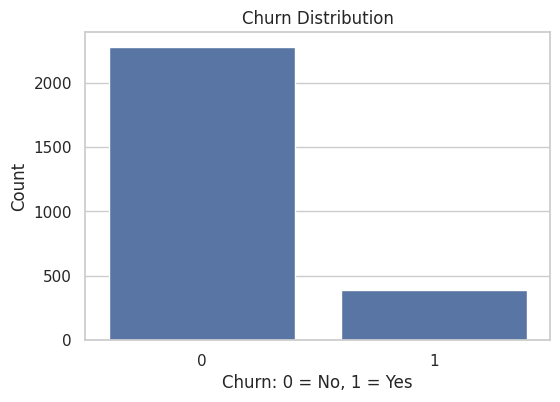

In [7]:
churn_counts = train_clean["Churn"].value_counts()
churn_rate = train_clean["Churn"].mean()

print("Churn Counts:")
print(churn_counts)

print("\nChurn Rate:")
print(round(churn_rate * 100, 3), "%")

plt.figure(figsize=(6, 4))
sns.countplot(data=train_clean, x="Churn")
plt.title("Churn Distribution")
plt.xlabel("Churn: 0 = No, 1 = Yes")
plt.ylabel("Count")
plt.show()

The churn rate shows the percentage of customers who left the telecom company. Since the number of non-churners is much higher than the number of churners, the dataset is imbalanced. This is important because accuracy alone may be misleading. A model can achieve high accuracy by mostly predicting the majority class, but it may perform poorly in identifying actual churners.

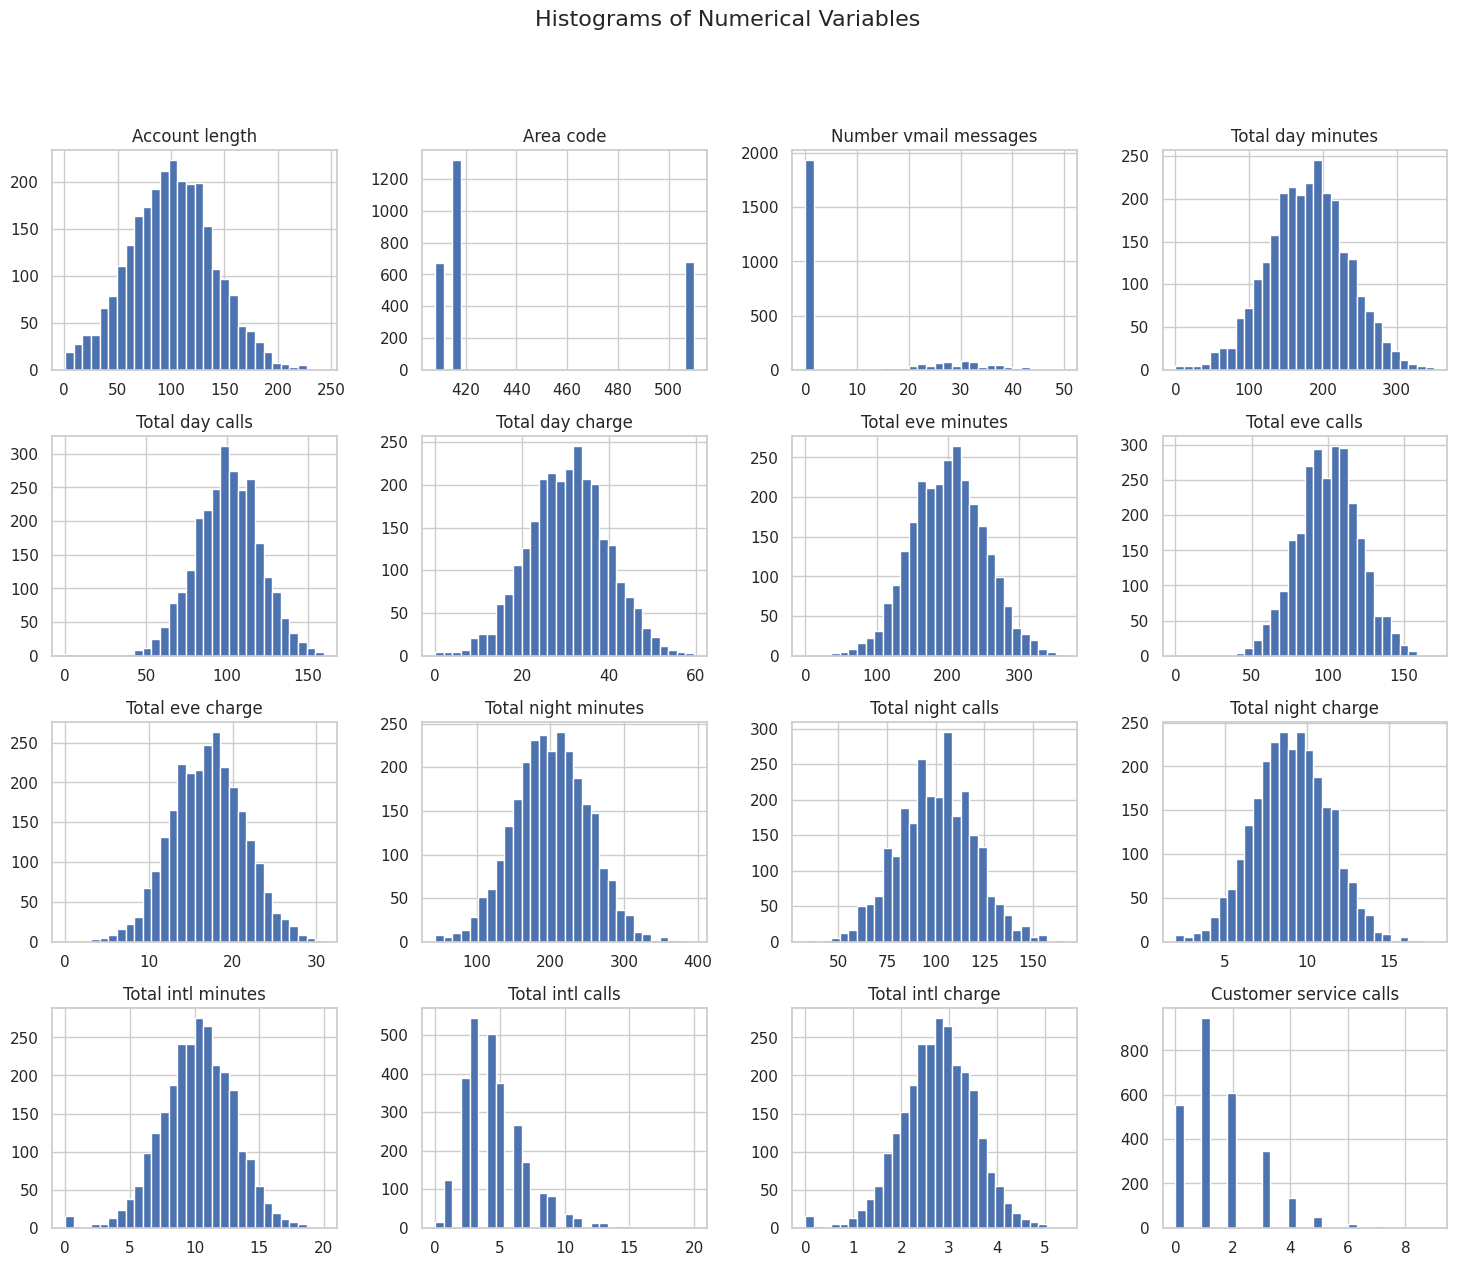

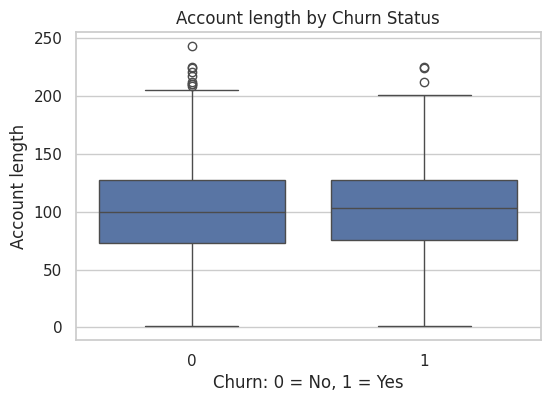

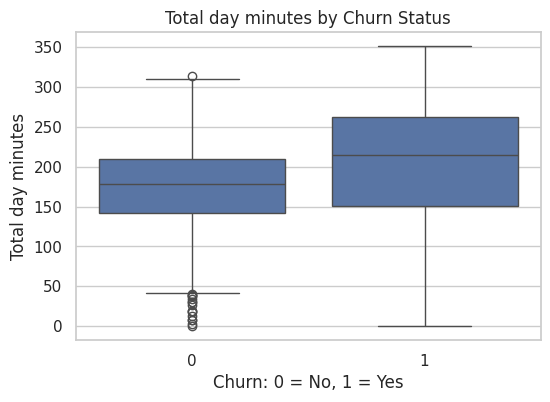

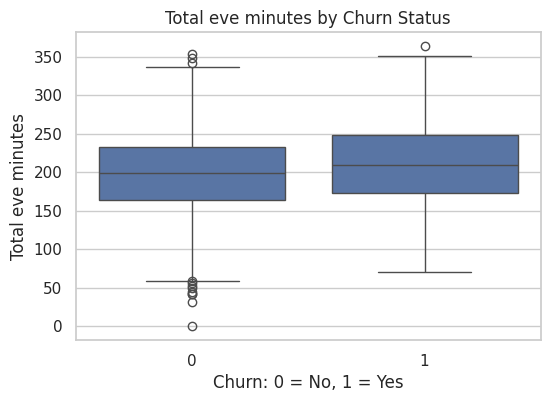

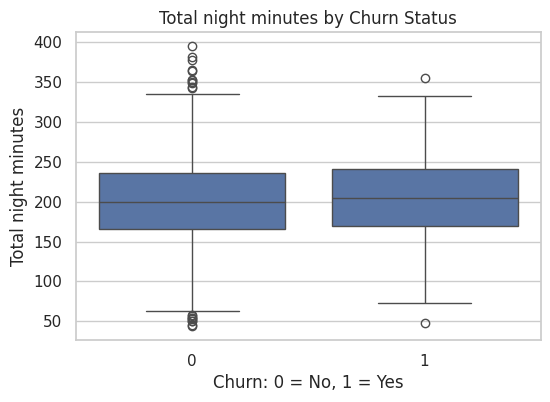

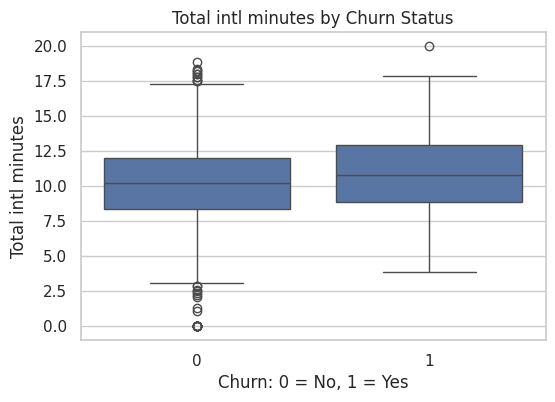

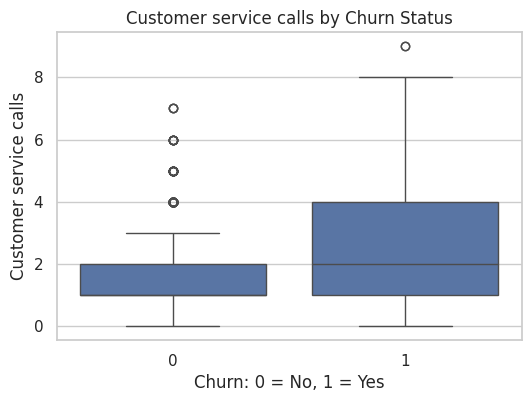

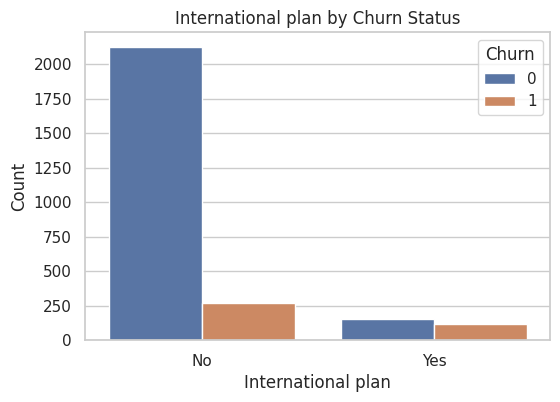

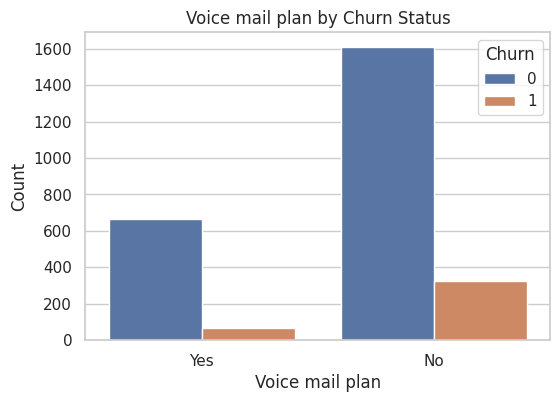

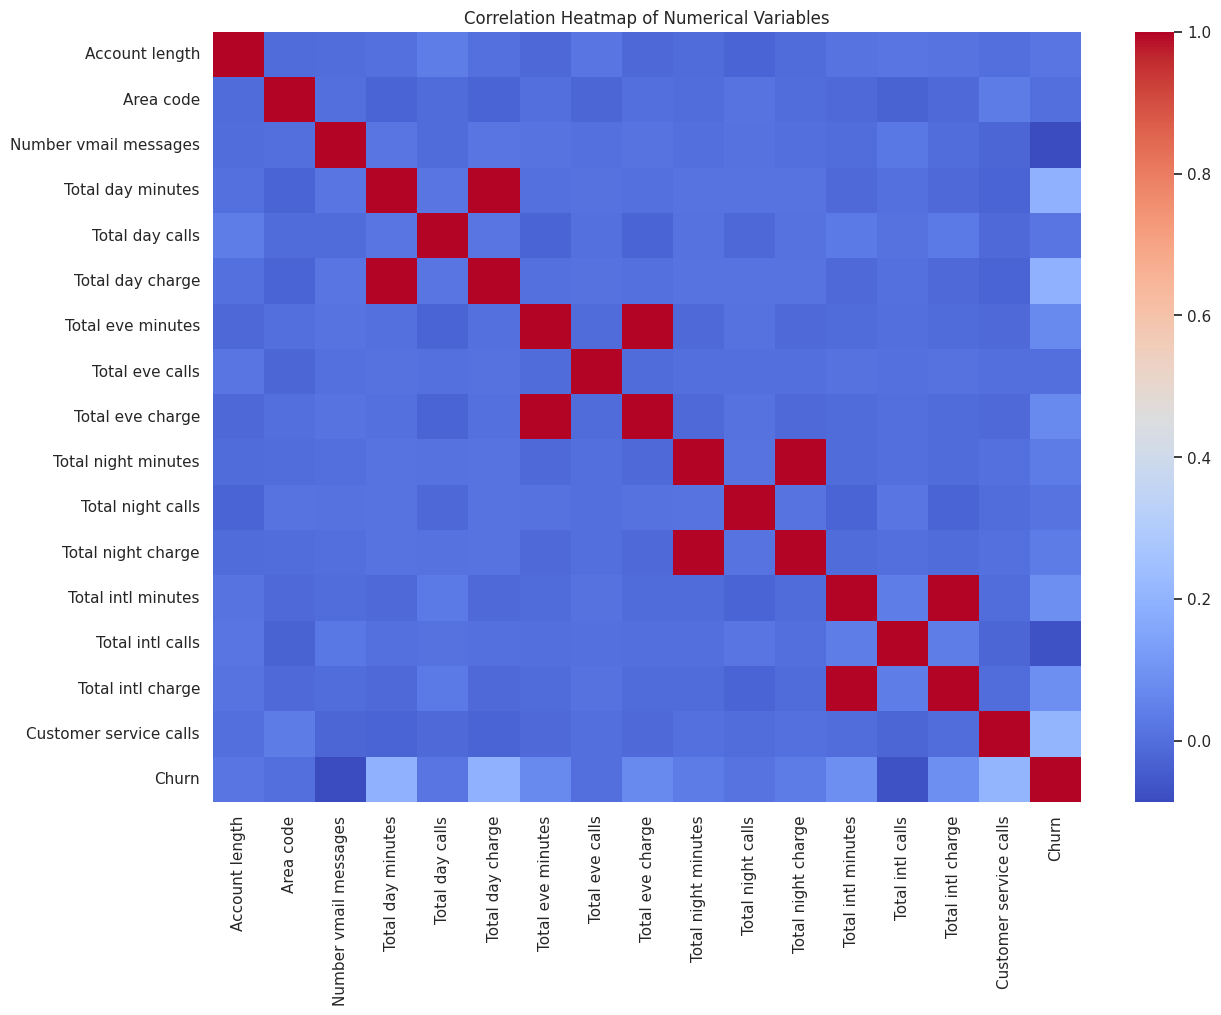

Correlation with Churn:


Churn                     1.000000
Customer service calls    0.202590
Total day charge          0.195689
Total day minutes         0.195688
Total intl charge         0.086216
Total intl minutes        0.086204
Total eve minutes         0.072906
Total eve charge          0.072893
Total night minutes       0.033639
Total night charge        0.033635
Total day calls           0.018290
Account length            0.017728
Total night calls         0.012262
Area code                 0.001019
Total eve calls          -0.001539
Total intl calls         -0.069882
Number vmail messages    -0.086474
Name: Churn, dtype: float64

Class Distribution Percentage:
Churn
0    85.446
1    14.554
Name: proportion, dtype: float64


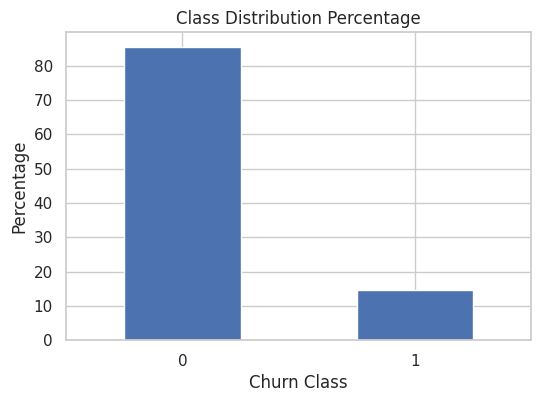

In [8]:
numeric_cols = train_clean.select_dtypes(include=["int64", "float64"]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != "Churn"]

train_clean[numeric_cols].hist(figsize=(18, 14), bins=30)
plt.suptitle("Histograms of Numerical Variables", fontsize=16)
plt.show()

important_vars = [
    "Account length",
    "Total day minutes",
    "Total eve minutes",
    "Total night minutes",
    "Total intl minutes",
    "Customer service calls"
]

for col in important_vars:
    if col in train_clean.columns:
        plt.figure(figsize=(6, 4))
        sns.boxplot(data=train_clean, x="Churn", y=col)
        plt.title(f"{col} by Churn Status")
        plt.xlabel("Churn: 0 = No, 1 = Yes")
        plt.ylabel(col)
        plt.show()


categorical_cols = train_clean.select_dtypes(include=["object", "bool"]).columns.tolist()

for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=train_clean, x=col, hue="Churn")
    plt.title(f"{col} by Churn Status")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.legend(title="Churn")
    plt.show()

corr_matrix = train_clean.select_dtypes(include=["int64", "float64"]).corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap of Numerical Variables")
plt.show()


churn_corr = corr_matrix["Churn"].sort_values(ascending=False)

print("Correlation with Churn:")
display(churn_corr)

class_distribution = y_train.value_counts(normalize=True) * 100

print("Class Distribution Percentage:")
print(class_distribution.round(3))

plt.figure(figsize=(6, 4))
class_distribution.plot(kind="bar")
plt.title("Class Distribution Percentage")
plt.xlabel("Churn Class")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.show()

The histograms show the distribution of numerical variables such as total minutes, total calls, charges, and customer service calls. Boxplots help compare the behavior of customers who churned versus those who did not.

Categorical variables such as International plan and Voice mail plan may influence churn behavior. For example, if customers with an international plan show a higher churn proportion, this may suggest dissatisfaction with international call pricing or service quality.

The correlation heatmap shows relationships between numerical variables. Some variables are expected to be highly correlated, especially total minutes and total charges.
Strong correlation between predictors may affect regression-based models because of multicollinearity. 

Tree-based models are usually less sensitive to this issue.The class imbalance examination shows whether churners and non-churners are equally represented. In telecom churn datasets, non-churners often dominate the dataset.

## III. Modeling and Comparison (25 points)


In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

results = []



### 1. Logistic Regression


Logistic Regression Cross-Validation ROC-AUC Scores:
[0.822 0.844 0.783 0.807 0.791]
Mean ROC-AUC: 0.809
Standard Deviation: 0.022

LOGISTIC REGRESSION RESULTS
Accuracy: 0.853
Precision: 0.459
Recall: 0.179
F1-score: 0.258
ROC-AUC: 0.826

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.97      0.92       572
           1       0.46      0.18      0.26        95

    accuracy                           0.85       667
   macro avg       0.67      0.57      0.59       667
weighted avg       0.82      0.85      0.82       667

Confusion Matrix:
[[552  20]
 [ 78  17]]


,Feature,Coefficient,Absolute Coefficient
17,Voice mail plan_Yes,-0.805614,0.805614
15,Customer service calls,0.662390,0.662390
16,International plan_Yes,0.630582,0.630582
2,Number vmail messages,0.413031,0.413031
5,Total day charge,0.340067,0.340067
3,Total day minutes,0.339970,0.339970
13,Total intl calls,-0.292668,0.292668
6,Total eve minutes,0.144220,0.144220
8,Total eve charge,0.142870,0.142870
14,Total intl charge,0.142173,0.142173


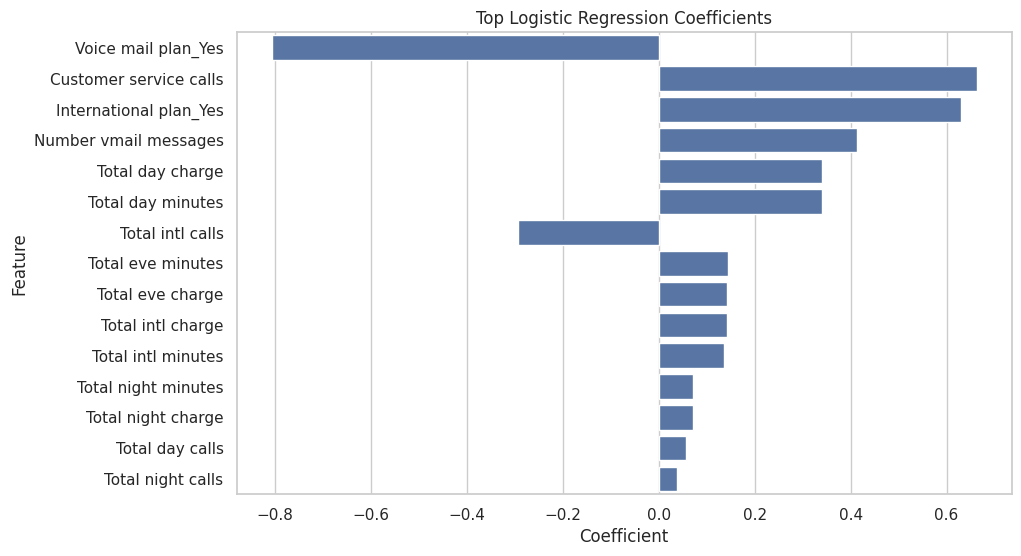

In [12]:
logistic_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

# Cross-validation using ROC-AUC
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

logistic_cv_scores = cross_val_score(
    logistic_model,
    X_train_encoded,
    y_train,
    cv=cv,
    scoring="roc_auc"
)

print("Logistic Regression Cross-Validation ROC-AUC Scores:")
print(logistic_cv_scores.round(3))
print("Mean ROC-AUC:", round(logistic_cv_scores.mean(), 3))
print("Standard Deviation:", round(logistic_cv_scores.std(), 3))

# Train model
logistic_model.fit(X_train_encoded, y_train)

# Predict
y_pred_logistic = logistic_model.predict(X_test_encoded)
y_prob_logistic = logistic_model.predict_proba(X_test_encoded)[:, 1]

# Evaluate
logistic_accuracy = accuracy_score(y_test, y_pred_logistic)
logistic_precision = precision_score(y_test, y_pred_logistic, zero_division=0)
logistic_recall = recall_score(y_test, y_pred_logistic, zero_division=0)
logistic_f1 = f1_score(y_test, y_pred_logistic, zero_division=0)
logistic_roc_auc = roc_auc_score(y_test, y_prob_logistic)

print("\nLOGISTIC REGRESSION RESULTS")
print("Accuracy:", round(logistic_accuracy, 3))
print("Precision:", round(logistic_precision, 3))
print("Recall:", round(logistic_recall, 3))
print("F1-score:", round(logistic_f1, 3))
print("ROC-AUC:", round(logistic_roc_auc, 3))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_logistic, zero_division=0))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_logistic))

# Store results
results.append({
    "Model": "Logistic Regression",
    "Accuracy": logistic_accuracy,
    "Precision": logistic_precision,
    "Recall": logistic_recall,
    "F1-score": logistic_f1,
    "ROC-AUC": logistic_roc_auc
})


logistic_coefficients = pd.DataFrame({
    "Feature": X_train_encoded.columns,
    "Coefficient": logistic_model.named_steps["model"].coef_[0]
})

logistic_coefficients["Absolute Coefficient"] = logistic_coefficients["Coefficient"].abs()

logistic_coefficients = logistic_coefficients.sort_values(
    by="Absolute Coefficient",
    ascending=False
)

display(logistic_coefficients.head(15))

plt.figure(figsize=(10, 6))
sns.barplot(
    data=logistic_coefficients.head(15),
    x="Coefficient",
    y="Feature"
)
plt.title("Top Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.show()

Logistic Regression was selected since the target variable churn is binary and it was designed for binary classification
problems so it's good as a baseline model.

It can also be easily interpreted since each coefficient shows whether a feature increases or decreases the probability of churn.

A positive coefficient means the feature increases the probability of churn. A negative coefficient means the feature decreases the probability of churn.

For example, if Customer service calls has a positive coefficient, this suggests that customers who contact customer service more often are more likely to churn. This may indicate dissatisfaction with the service.

If Voice mail plan_Yes has a negative coefficient, this suggests that customers with a voice mail plan may be less likely to churn.

Logistic Regression predicts churn by estimating the probability that a customer belongs to class 1. If the predicted probability is greater than the default threshold of 0.5, the customer is classified as a churner. Otherwise, the customer is classified as a non-churner.

### 2. Lasso Regression

Lasso Logistic Regression Cross-Validation ROC-AUC Scores:
[0.822 0.844 0.783 0.806 0.792]
Mean ROC-AUC: 0.809
Standard Deviation: 0.022

LASSO LOGISTIC REGRESSION RESULTS
Accuracy: 0.853
Precision: 0.459
Recall: 0.179
F1-score: 0.258
ROC-AUC: 0.826

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.97      0.92       572
           1       0.46      0.18      0.26        95

    accuracy                           0.85       667
   macro avg       0.67      0.57      0.59       667
weighted avg       0.82      0.85      0.82       667

Confusion Matrix:
[[552  20]
 [ 78  17]]


,Feature,Coefficient,Absolute Coefficient
17,Voice mail plan_Yes,-0.738525,0.738525
15,Customer service calls,0.657620,0.657620
16,International plan_Yes,0.627473,0.627473
3,Total day minutes,0.619416,0.619416
2,Number vmail messages,0.349409,0.349409
13,Total intl calls,-0.286929,0.286929
14,Total intl charge,0.273429,0.273429
8,Total eve charge,0.201178,0.201178
9,Total night minutes,0.093719,0.093719
6,Total eve minutes,0.080249,0.080249


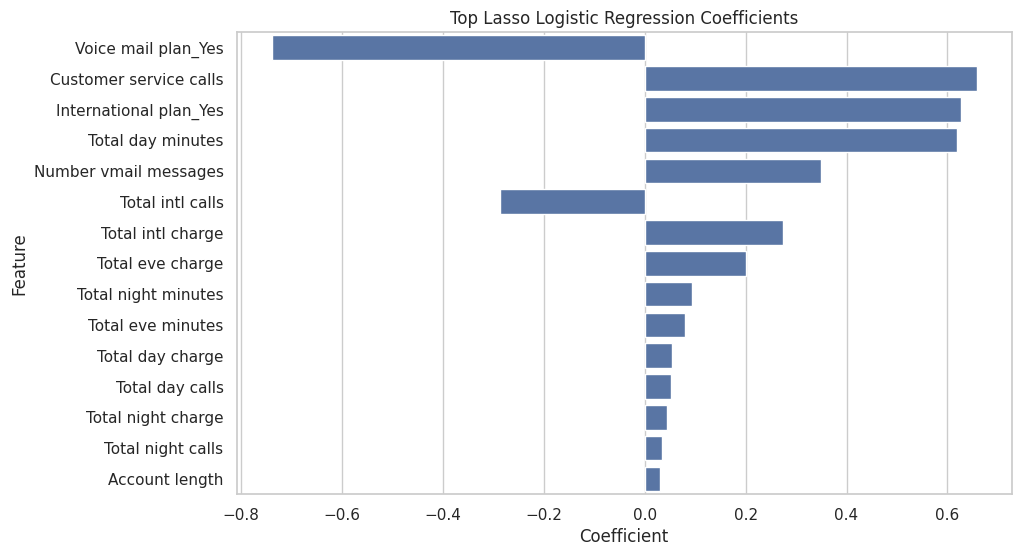

In [16]:
lasso_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        penalty="l1",
        solver="liblinear",
        max_iter=1000,
        random_state=42
    ))
])

# Cross-validation using ROC-AUC
lasso_cv_scores = cross_val_score(
    lasso_model,
    X_train_encoded,
    y_train,
    cv=cv,
    scoring="roc_auc"
)

print("Lasso Logistic Regression Cross-Validation ROC-AUC Scores:")
print(lasso_cv_scores.round(3))
print("Mean ROC-AUC:", round(lasso_cv_scores.mean(), 3))
print("Standard Deviation:", round(lasso_cv_scores.std(), 3))

# Train the model
lasso_model.fit(X_train_encoded, y_train)

# Predictions
y_pred_lasso = lasso_model.predict(X_test_encoded)
y_prob_lasso = lasso_model.predict_proba(X_test_encoded)[:, 1]

# Evaluation metrics
lasso_accuracy = accuracy_score(y_test, y_pred_lasso)
lasso_precision = precision_score(y_test, y_pred_lasso, zero_division=0)
lasso_recall = recall_score(y_test, y_pred_lasso, zero_division=0)
lasso_f1 = f1_score(y_test, y_pred_lasso, zero_division=0)
lasso_roc_auc = roc_auc_score(y_test, y_prob_lasso)

print("\nLASSO LOGISTIC REGRESSION RESULTS")
print("Accuracy:", round(lasso_accuracy, 3))
print("Precision:", round(lasso_precision, 3))
print("Recall:", round(lasso_recall, 3))
print("F1-score:", round(lasso_f1, 3))
print("ROC-AUC:", round(lasso_roc_auc, 3))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lasso, zero_division=0))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lasso))

# Store results
results.append({
    "Model": "Lasso Logistic Regression",
    "Accuracy": lasso_accuracy,
    "Precision": lasso_precision,
    "Recall": lasso_recall,
    "F1-score": lasso_f1,
    "ROC-AUC": lasso_roc_auc
})

lasso_coefficients = pd.DataFrame({
    "Feature": X_train_encoded.columns,
    "Coefficient": lasso_model.named_steps["model"].coef_[0]
})

lasso_coefficients["Absolute Coefficient"] = lasso_coefficients["Coefficient"].abs()

lasso_coefficients = lasso_coefficients.sort_values(
    by="Absolute Coefficient",
    ascending=False
)

display(lasso_coefficients.head(15))

plt.figure(figsize=(10, 6))
sns.barplot(
    data=lasso_coefficients.head(15),
    x="Coefficient",
    y="Feature"
)
plt.title("Top Lasso Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.show()

Lasso was selected since it's still appropriate to predict the probability that a customer will churn and here in Lasso, weak predictors are regulated by shrinking some coefficients
close to zero. 

A positive coefficient means that the feature increases the probability of churn, while a negative coefficient means that the feature decreases the probability of churn.

Because Lasso uses L1 regularization, some coefficients may become very small or exactly zero. These features have weak influence on the prediction.

The model’s decision behavior is similar to Logistic Regression. It estimates the probability that a customer will churn. If the probability is above the classification threshold, usually 0.5, the customer is classified as a churner.

### 3. Decision Tree

Decision Tree Cross-Validation ROC-AUC Scores:
[0.83  0.896 0.873 0.886 0.9  ]
Mean ROC-AUC: 0.877
Standard Deviation: 0.025

DECISION TREE RESULTS
Accuracy: 0.948
Precision: 0.857
Recall: 0.758
F1-score: 0.804
ROC-AUC: 0.905

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       572
           1       0.86      0.76      0.80        95

    accuracy                           0.95       667
   macro avg       0.91      0.87      0.89       667
weighted avg       0.95      0.95      0.95       667

Confusion Matrix:
[[560  12]
 [ 23  72]]


,Feature,Importance
5,Total day charge,0.205618
15,Customer service calls,0.163592
14,Total intl charge,0.125662
16,International plan_Yes,0.120882
13,Total intl calls,0.106851
6,Total eve minutes,0.103583
3,Total day minutes,0.102164
2,Number vmail messages,0.049016
8,Total eve charge,0.018783
9,Total night minutes,0.003847


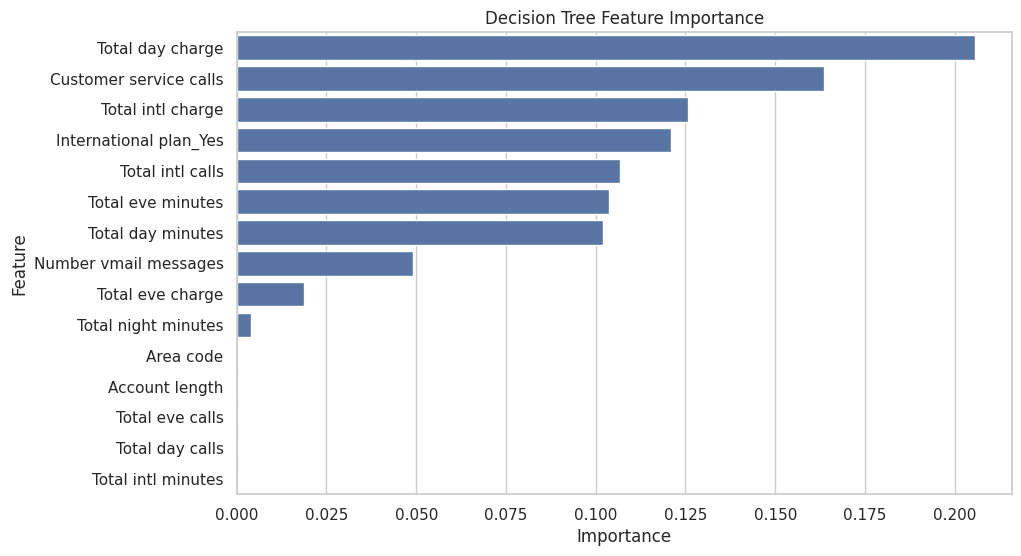

In [18]:
decision_tree_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

# Cross-validation using ROC-AUC
dt_cv_scores = cross_val_score(
    decision_tree_model,
    X_train_encoded,
    y_train,
    cv=cv,
    scoring="roc_auc"
)

print("Decision Tree Cross-Validation ROC-AUC Scores:")
print(dt_cv_scores.round(3))
print("Mean ROC-AUC:", round(dt_cv_scores.mean(), 3))
print("Standard Deviation:", round(dt_cv_scores.std(), 3))

# Train the model
decision_tree_model.fit(X_train_encoded, y_train)

# Predictions
y_pred_dt = decision_tree_model.predict(X_test_encoded)
y_prob_dt = decision_tree_model.predict_proba(X_test_encoded)[:, 1]

# Evaluation metrics
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt, zero_division=0)
dt_recall = recall_score(y_test, y_pred_dt, zero_division=0)
dt_f1 = f1_score(y_test, y_pred_dt, zero_division=0)
dt_roc_auc = roc_auc_score(y_test, y_prob_dt)

print("\nDECISION TREE RESULTS")
print("Accuracy:", round(dt_accuracy, 3))
print("Precision:", round(dt_precision, 3))
print("Recall:", round(dt_recall, 3))
print("F1-score:", round(dt_f1, 3))
print("ROC-AUC:", round(dt_roc_auc, 3))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt, zero_division=0))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

# Store results
results.append({
    "Model": "Decision Tree",
    "Accuracy": dt_accuracy,
    "Precision": dt_precision,
    "Recall": dt_recall,
    "F1-score": dt_f1,
    "ROC-AUC": dt_roc_auc
})

dt_importance = pd.DataFrame({
    "Feature": X_train_encoded.columns,
    "Importance": decision_tree_model.feature_importances_
})

dt_importance = dt_importance.sort_values(
    by="Importance",
    ascending=False
)

display(dt_importance.head(15))

plt.figure(figsize=(10, 6))
sns.barplot(
    data=dt_importance.head(15),
    x="Importance",
    y="Feature"
)
plt.title("Decision Tree Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

A Decision Tree was selected because it can model nonlinear relationships between customer features and churn. Unlike Logistic Regression, it does not assume a linear relationship between the predictors and the target variable.

It is like an if-then statement but using a model. Features with higher importance values are more influential in splitting the data and separating churners from non-churners.

The model’s decision behavior follows an if-then structure. However, a Decision Tree can overfit if it becomes too deep. To reduce overfitting, the model used limits such as max_depth, min_samples_split, and min_samples_leaf.

### 4. Random Forest Classifier

Random Forest Cross-Validation ROC-AUC Scores:
[0.885 0.912 0.899 0.915 0.937]
Mean ROC-AUC: 0.91
Standard Deviation: 0.017

RANDOM FOREST RESULTS
Accuracy: 0.966
Precision: 0.939
Recall: 0.811
F1-score: 0.87
ROC-AUC: 0.925

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       572
           1       0.94      0.81      0.87        95

    accuracy                           0.97       667
   macro avg       0.95      0.90      0.93       667
weighted avg       0.96      0.97      0.96       667

Confusion Matrix:
[[567   5]
 [ 18  77]]


,Feature,Importance
15,Customer service calls,0.157632
3,Total day minutes,0.129178
5,Total day charge,0.128269
16,International plan_Yes,0.099113
6,Total eve minutes,0.055694
8,Total eve charge,0.055342
12,Total intl minutes,0.042256
14,Total intl charge,0.042158
13,Total intl calls,0.041173
9,Total night minutes,0.037753


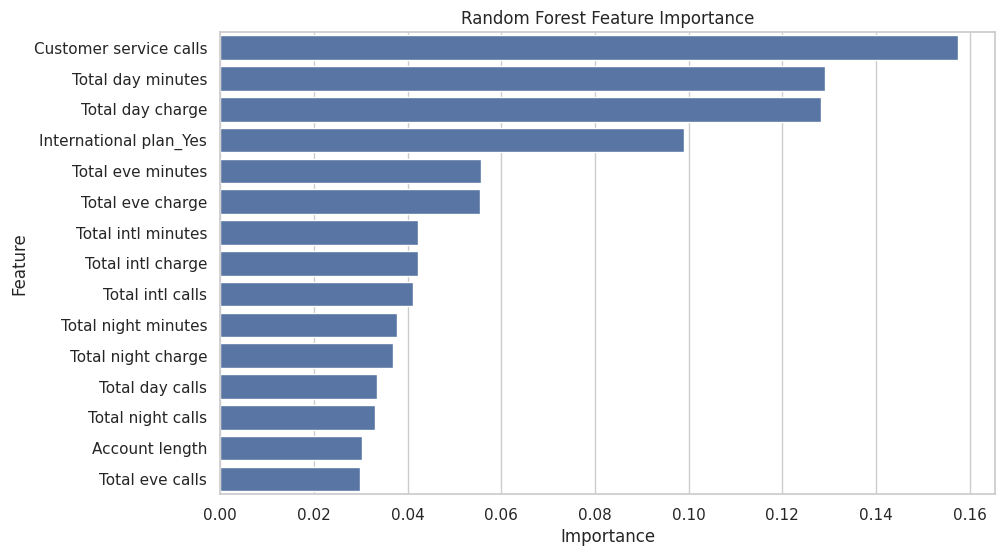

In [20]:
random_forest_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42
)

# Cross-validation using ROC-AUC
rf_cv_scores = cross_val_score(
    random_forest_model,
    X_train_encoded,
    y_train,
    cv=cv,
    scoring="roc_auc"
)

print("Random Forest Cross-Validation ROC-AUC Scores:")
print(rf_cv_scores.round(3))
print("Mean ROC-AUC:", round(rf_cv_scores.mean(), 3))
print("Standard Deviation:", round(rf_cv_scores.std(), 3))

# Train the model
random_forest_model.fit(X_train_encoded, y_train)

# Predictions
y_pred_rf = random_forest_model.predict(X_test_encoded)
y_prob_rf = random_forest_model.predict_proba(X_test_encoded)[:, 1]

# Evaluation metrics
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf, zero_division=0)
rf_recall = recall_score(y_test, y_pred_rf, zero_division=0)
rf_f1 = f1_score(y_test, y_pred_rf, zero_division=0)
rf_roc_auc = roc_auc_score(y_test, y_prob_rf)

print("\nRANDOM FOREST RESULTS")
print("Accuracy:", round(rf_accuracy, 3))
print("Precision:", round(rf_precision, 3))
print("Recall:", round(rf_recall, 3))
print("F1-score:", round(rf_f1, 3))
print("ROC-AUC:", round(rf_roc_auc, 3))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, zero_division=0))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

# Store results
results.append({
    "Model": "Random Forest",
    "Accuracy": rf_accuracy,
    "Precision": rf_precision,
    "Recall": rf_recall,
    "F1-score": rf_f1,
    "ROC-AUC": rf_roc_auc
})

rf_importance = pd.DataFrame({
    "Feature": X_train_encoded.columns,
    "Importance": random_forest_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
)

display(rf_importance.head(15))

plt.figure(figsize=(10, 6))
sns.barplot(
    data=rf_importance.head(15),
    x="Importance",
    y="Feature"
)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

Random Forest was selected because it improves the performance of a single Decision Tree by combining many trees. Each tree is trained on a different sample of the data, and the final prediction is based on the majority vote of the trees making Random Forest more stable and less likely to overfit than a single Decision Tree.

Random Forest is interpreted using feature importance values. These values show which variables contribute most to the prediction across all trees in the forest.

Compared with a single Decision Tree, Random Forest has better stability because it averages the predictions of many trees. Its decision behavior is based on majority voting. Each tree gives a prediction, and the class with the most votes becomes the final prediction.

Random Forest is usually less interpretable than a single Decision Tree, but it often provides better predictive performance.


### 5. Gradient Boosting Classifier

Gradient Boosting Cross-Validation ROC-AUC Scores:
[0.907 0.909 0.899 0.924 0.927]
Mean ROC-AUC: 0.913
Standard Deviation: 0.01

GRADIENT BOOSTING RESULTS
Accuracy: 0.949
Precision: 0.93
Recall: 0.695
F1-score: 0.795
ROC-AUC: 0.925

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       572
           1       0.93      0.69      0.80        95

    accuracy                           0.95       667
   macro avg       0.94      0.84      0.88       667
weighted avg       0.95      0.95      0.95       667

Confusion Matrix:
[[567   5]
 [ 29  66]]


,Feature,Importance
5,Total day charge,0.174645
15,Customer service calls,0.172314
16,International plan_Yes,0.105823
13,Total intl calls,0.096080
3,Total day minutes,0.090504
6,Total eve minutes,0.080911
14,Total intl charge,0.065707
8,Total eve charge,0.052029
12,Total intl minutes,0.051325
2,Number vmail messages,0.049465


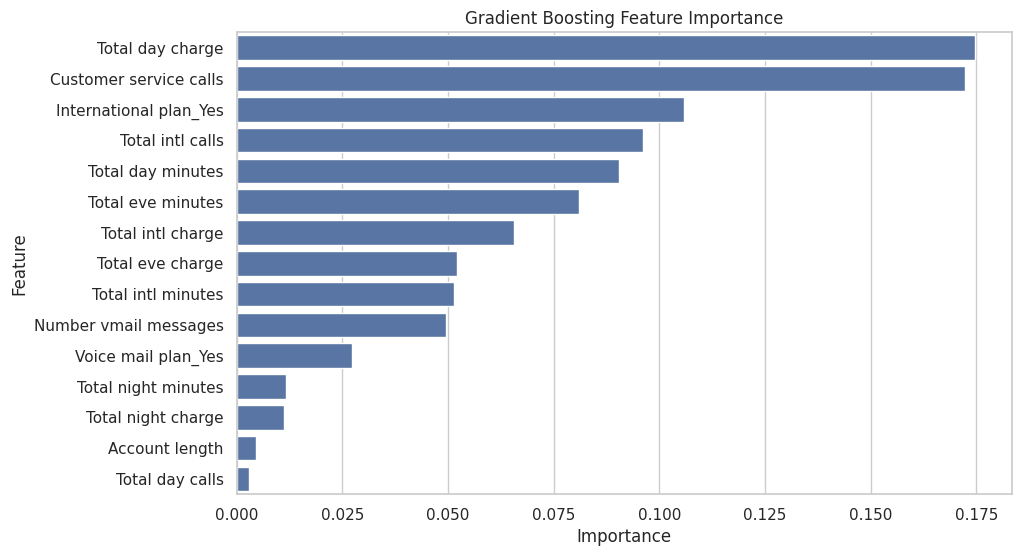

In [21]:
gradient_boosting_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

# Cross-validation using ROC-AUC
gb_cv_scores = cross_val_score(
    gradient_boosting_model,
    X_train_encoded,
    y_train,
    cv=cv,
    scoring="roc_auc"
)

print("Gradient Boosting Cross-Validation ROC-AUC Scores:")
print(gb_cv_scores.round(3))
print("Mean ROC-AUC:", round(gb_cv_scores.mean(), 3))
print("Standard Deviation:", round(gb_cv_scores.std(), 3))

# Train the model
gradient_boosting_model.fit(X_train_encoded, y_train)

# Predictions
y_pred_gb = gradient_boosting_model.predict(X_test_encoded)
y_prob_gb = gradient_boosting_model.predict_proba(X_test_encoded)[:, 1]

# Evaluation metrics
gb_accuracy = accuracy_score(y_test, y_pred_gb)
gb_precision = precision_score(y_test, y_pred_gb, zero_division=0)
gb_recall = recall_score(y_test, y_pred_gb, zero_division=0)
gb_f1 = f1_score(y_test, y_pred_gb, zero_division=0)
gb_roc_auc = roc_auc_score(y_test, y_prob_gb)

print("\nGRADIENT BOOSTING RESULTS")
print("Accuracy:", round(gb_accuracy, 3))
print("Precision:", round(gb_precision, 3))
print("Recall:", round(gb_recall, 3))
print("F1-score:", round(gb_f1, 3))
print("ROC-AUC:", round(gb_roc_auc, 3))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb, zero_division=0))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_gb))

# Store results
results.append({
    "Model": "Gradient Boosting",
    "Accuracy": gb_accuracy,
    "Precision": gb_precision,
    "Recall": gb_recall,
    "F1-score": gb_f1,
    "ROC-AUC": gb_roc_auc
})

gb_importance = pd.DataFrame({
    "Feature": X_train_encoded.columns,
    "Importance": gradient_boosting_model.feature_importances_
})

gb_importance = gb_importance.sort_values(
    by="Importance",
    ascending=False
)

display(gb_importance.head(15))

plt.figure(figsize=(10, 6))
sns.barplot(
    data=gb_importance.head(15),
    x="Importance",
    y="Feature"
)
plt.title("Gradient Boosting Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

Gradient Boosting was selected because it is a strong tree-based ensemble method. It builds trees sequentially, where each new tree tries to correct the errors made by the previous trees.

This makes it effective for detecting complex patterns in customer churn.

Features with higher importance values contributed more to reducing prediction error.

Its decision behavior is different from Random Forest because the trees are built sequentially rather than independently. Each tree focuses on correcting previous mistakes. This allows Gradient Boosting to capture complex patterns in the data.

However, Gradient Boosting is less interpretable than Logistic Regression or a single Decision Tree because the final prediction comes from many trees working together.



#### Model Performance Comparison

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.853,0.459,0.179,0.258,0.826
1,Lasso Logistic Regression,0.853,0.459,0.179,0.258,0.826
2,Decision Tree,0.948,0.857,0.758,0.804,0.905
3,Random Forest,0.966,0.939,0.811,0.870,0.925
4,Random Forest,0.966,0.939,0.811,0.870,0.925
5,Gradient Boosting,0.949,0.930,0.695,0.795,0.925


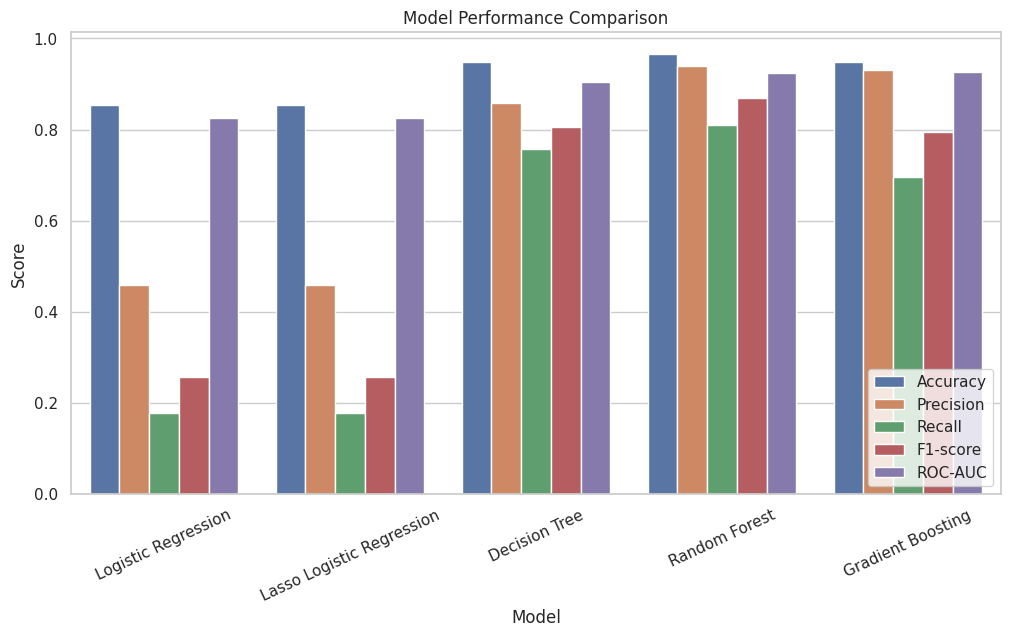

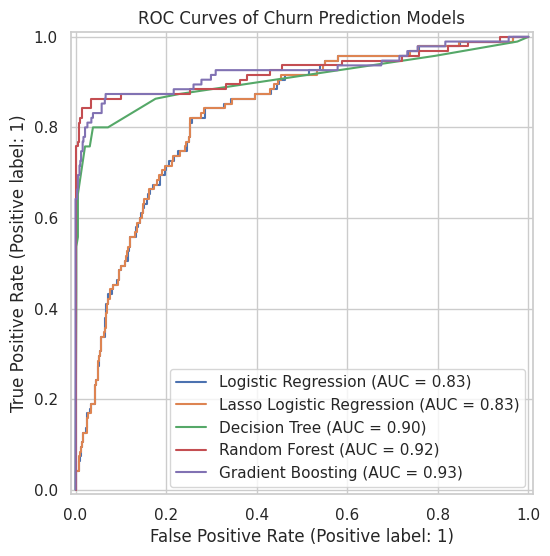

Best Model Based on ROC-AUC:
Model        Gradient Boosting
Accuracy              0.949025
Precision             0.929577
Recall                0.694737
F1-score              0.795181
ROC-AUC               0.925202
Name: 5, dtype: object


In [23]:
results_df = pd.DataFrame(results)

results_df_rounded = results_df.copy()

for col in ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]:
    results_df_rounded[col] = results_df_rounded[col].round(3)

display(results_df_rounded)

results_melted = results_df.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=results_melted,
    x="Model",
    y="Score",
    hue="Metric"
)
plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=25)
plt.legend(loc="lower right")
plt.show()

plt.figure(figsize=(8, 6))

RocCurveDisplay.from_estimator(
    logistic_model,
    X_test_encoded,
    y_test,
    name="Logistic Regression",
    ax=plt.gca()
)

RocCurveDisplay.from_estimator(
    lasso_model,
    X_test_encoded,
    y_test,
    name="Lasso Logistic Regression",
    ax=plt.gca()
)

RocCurveDisplay.from_estimator(
    decision_tree_model,
    X_test_encoded,
    y_test,
    name="Decision Tree",
    ax=plt.gca()
)

RocCurveDisplay.from_estimator(
    random_forest_model,
    X_test_encoded,
    y_test,
    name="Random Forest",
    ax=plt.gca()
)

RocCurveDisplay.from_estimator(
    gradient_boosting_model,
    X_test_encoded,
    y_test,
    name="Gradient Boosting",
    ax=plt.gca()
)

plt.title("ROC Curves of Churn Prediction Models")
plt.show()

best_model = results_df.sort_values(by="ROC-AUC", ascending=False).iloc[0]

print("Best Model Based on ROC-AUC:")
print(best_model)

## IV. Conclusion and Interpretation (10 points)

#### Best Performing Model

The best-performing model is identified based on the highest ROC-AUC and F1-score. ROC-AUC is important because it measures how well the model separates churners from non-churners. F1-score is also important because it balances precision and recall.

In churn prediction, recall is especially important because the company wants to correctly identify customers who are likely to leave. If the model fails to detect churners, the company may lose customers without giving them retention offers.

Gradient Boosting performed best meaning that churn behavior is influenced by nonlinear relationships and interactions among customer features instead of just a linear relationship.



#### Bias-Variance Trade-Off


Logistic Regression and Lasso Logistic Regression have higher bias but lower variance. They are simpler models and may not fully capture complex relationships in the dataset.

The Decision Tree has lower bias but higher variance. It can capture complex rules, but it may overfit if it becomes too deep.

Random Forest reduces variance by averaging many decision trees. This makes it more stable than a single tree.

Gradient Boosting can reduce bias by sequentially correcting errors, but it can overfit if too many trees are used or if the learning rate is not properly controlled.

#### Interpretability vs Predictive Performance

There is a trade-off between interpretability and predictive performance.

Logistic Regression and Lasso Logistic Regression are easier to interpret because their coefficients show how each feature affects churn probability.

Decision Tree is also interpretable because it uses clear decision rules.

Random Forest and Gradient Boosting usually provide stronger predictive performance, but they are less interpretable because their predictions come from many trees. However, feature importance can still be used to understand which variables contribute most to churn prediction.

#### Real life applications
Telecom companies can use churn prediction models to retain customers, target their marketing better, and improve their service. They can use it to identify customers with hugh
churn probability and offer discounts or loyalty rewards to further encourage customers to keep on using their service. They can also use it for targeted marketing
where the company can focus campaigns on who are most likely to leave so they won't lose customers. For service improvements they can use it to identify which customers
has a high volume of service calls which may suggest unresolved complaints or issues.

# PART II — Deep Learning Classification Task (40 Points)
# Neural Networks and Logistic Regression on the Default Dataset

## I. Data Preparation and Exploration (8 points)
### A. Dataset Loading and Inspection (3 points)

In [35]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# For reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Load dataset
df = pd.read_csv("/kaggle/input/datasets/drei04/default1/Default.csv")

# Display first few rows
df.head()
print("Dataset dimensions:", df.shape)
print("Variable types:")
print(df.dtypes)
print("Summary statistics:")
display(df.describe(include="all"))
print("Missing values:")
print(df.isnull().sum())

Dataset dimensions: (10000, 5)
Variable types:
rownames      int64
default      object
student      object
balance     float64
income      float64
dtype: object
Summary statistics:


,rownames,default,student,balance,income
count,10000.00000,10000,10000,10000.000000,10000.000000
unique,NaN,2,2,NaN,NaN
top,NaN,No,No,NaN,NaN
freq,NaN,9667,7056,NaN,NaN
mean,5000.50000,NaN,NaN,835.374886,33516.981876
std,2886.89568,NaN,NaN,483.714985,13336.639563
min,1.00000,NaN,NaN,0.000000,771.967729
25%,2500.75000,NaN,NaN,481.731105,21340.462903
50%,5000.50000,NaN,NaN,823.636973,34552.644802
75%,7500.25000,NaN,NaN,1166.308386,43807.729272


Missing values:
rownames    0
default     0
student     0
balance     0
income      0
dtype: int64


### B. Data Preprocessing (5 points)

Unique values in default:
['No' 'Yes']

Unique values in student:
['No' 'Yes']
Variable types after encoding:
default      int64
student      int64
balance    float64
income     float64
dtype: object
Predictors:


,student,balance,income
0,0,729.526495,44361.625074
1,1,817.180407,12106.134700
2,0,1073.549164,31767.138947
3,0,529.250605,35704.493935
4,0,785.655883,38463.495879


Response variable:


0    0
1    0
2    0
3    0
4    0
Name: default, dtype: int64

Training set shape: (8000, 3)
Testing set shape: (2000, 3)

Training target distribution:
default
0    0.96675
1    0.03325
Name: proportion, dtype: float64

Testing target distribution:
default
0    0.9665
1    0.0335
Name: proportion, dtype: float64


,student,balance,income
0,1.546372,-0.018061,-0.331140
1,-0.646675,-1.687480,2.194023
2,-0.646675,-0.123917,-0.288274
3,-0.646675,0.155670,0.992420
4,1.546372,0.449485,-1.673192


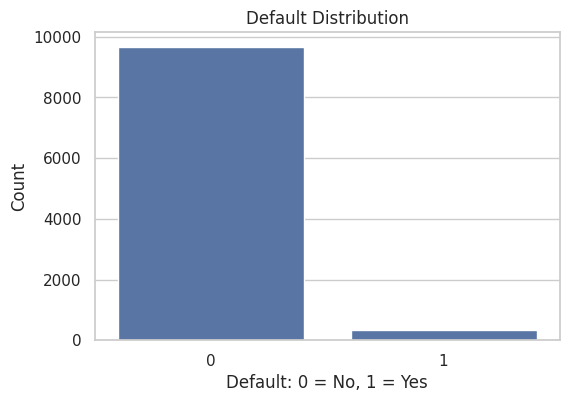

Default rate: 3.33 %


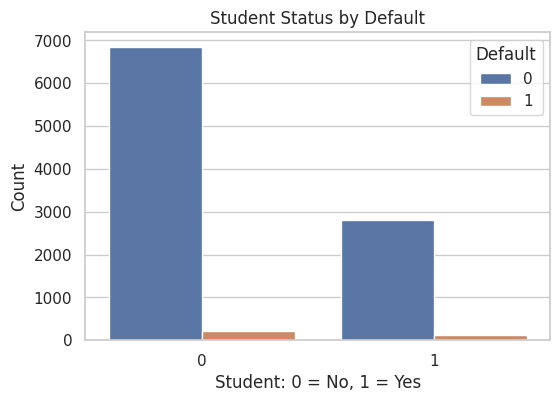

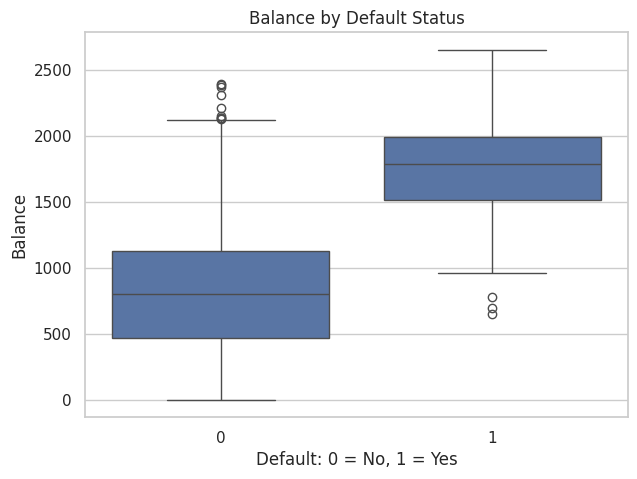

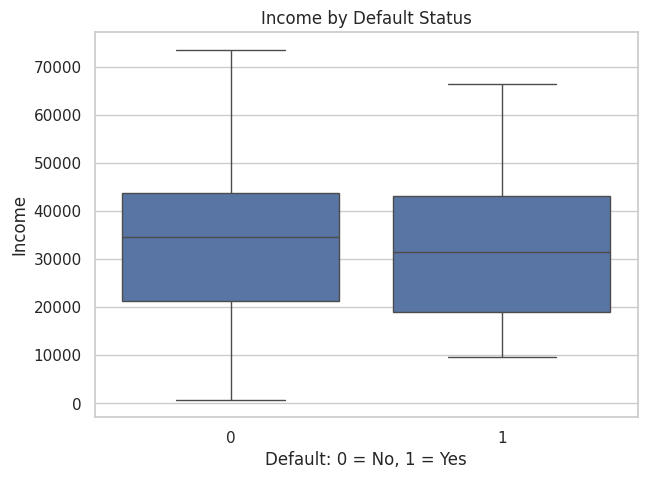

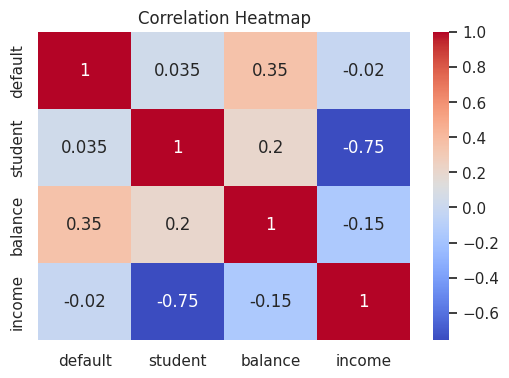

In [36]:
df_clean = df.copy()

# Drop rownames column if it exists
if "rownames" in df_clean.columns:
    df_clean = df_clean.drop(columns=["rownames"])

# Check unique values of categorical variables
print("Unique values in default:")
print(df_clean["default"].unique())

print("\nUnique values in student:")
print(df_clean["student"].unique())
df_clean["default"] = df_clean["default"].map({"No": 0, "Yes": 1})
df_clean["student"] = df_clean["student"].map({"No": 0, "Yes": 1})

df_clean.head()

print("Variable types after encoding:")
print(df_clean.dtypes)

X = df_clean[["student", "balance", "income"]]
y = df_clean["default"]

print("Predictors:")
display(X.head())

print("Response variable:")
display(y.head())

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back into DataFrames for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

display(X_train_scaled.head())

plt.figure(figsize=(6, 4))
sns.countplot(data=df_clean, x="default")
plt.title("Default Distribution")
plt.xlabel("Default: 0 = No, 1 = Yes")
plt.ylabel("Count")
plt.show()

default_rate = df_clean["default"].mean()
print("Default rate:", round(default_rate * 100, 3), "%")

plt.figure(figsize=(6, 4))
sns.countplot(data=df_clean, x="student", hue="default")
plt.title("Student Status by Default")
plt.xlabel("Student: 0 = No, 1 = Yes")
plt.ylabel("Count")
plt.legend(title="Default")
plt.show()

plt.figure(figsize=(7, 5))
sns.boxplot(data=df_clean, x="default", y="balance")
plt.title("Balance by Default Status")
plt.xlabel("Default: 0 = No, 1 = Yes")
plt.ylabel("Balance")
plt.show()

plt.figure(figsize=(7, 5))
sns.boxplot(data=df_clean, x="default", y="income")
plt.title("Income by Default Status")
plt.xlabel("Default: 0 = No, 1 = Yes")
plt.ylabel("Income")
plt.show()

plt.figure(figsize=(6, 4))
sns.heatmap(df_clean.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## II. Logistic Regression Model (8 points)
### A. Model Construction (4 points)

Logistic Regression model successfully fitted.


,Predictor,Coefficient,Absolute Coefficient
1,balance,2.712585,2.712585
0,student,-0.283076,0.283076
2,income,-0.033903,0.033903


LOGISTIC REGRESSION RESULTS
Accuracy: 0.973
ROC-AUC: 0.948

Confusion Matrix:
[[1925    8]
 [  46   21]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1933
           1       0.72      0.31      0.44        67

    accuracy                           0.97      2000
   macro avg       0.85      0.65      0.71      2000
weighted avg       0.97      0.97      0.97      2000



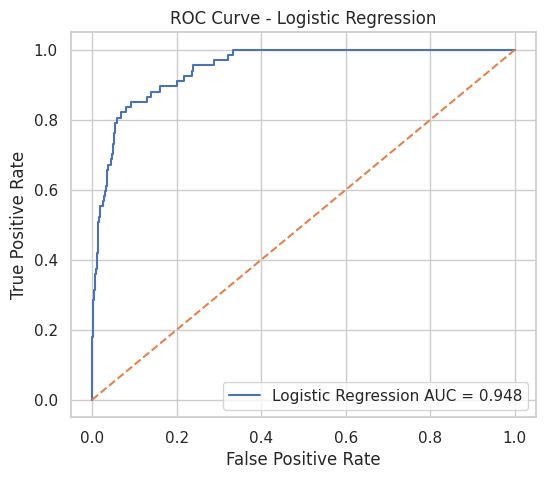

In [37]:
logistic_model = LogisticRegression(random_state=42)

logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression model successfully fitted.")

logistic_coefficients = pd.DataFrame({
    "Predictor": X.columns,
    "Coefficient": logistic_model.coef_[0]
})

logistic_coefficients["Absolute Coefficient"] = logistic_coefficients["Coefficient"].abs()

logistic_coefficients = logistic_coefficients.sort_values(
    by="Absolute Coefficient",
    ascending=False
)

display(logistic_coefficients)

y_pred_logistic = logistic_model.predict(X_test_scaled)

# Predicted probabilities for ROC-AUC
y_prob_logistic = logistic_model.predict_proba(X_test_scaled)[:, 1]

# Evaluation metrics
logistic_accuracy = accuracy_score(y_test, y_pred_logistic)
logistic_auc = roc_auc_score(y_test, y_prob_logistic)
logistic_cm = confusion_matrix(y_test, y_pred_logistic)

print("LOGISTIC REGRESSION RESULTS")
print("Accuracy:", round(logistic_accuracy, 3))
print("ROC-AUC:", round(logistic_auc, 3))

print("\nConfusion Matrix:")
print(logistic_cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_logistic, zero_division=0))

fpr_logistic, tpr_logistic, thresholds_logistic = roc_curve(y_test, y_prob_logistic)

plt.figure(figsize=(6, 5))
plt.plot(fpr_logistic, tpr_logistic, label=f"Logistic Regression AUC = {logistic_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

The response variable is default, while the predictors are student, balance, and income.

### B. Performance Evaluation (4 points)

LOGISTIC REGRESSION RESULTS
Accuracy: 0.973
ROC-AUC: 0.948

Confusion Matrix:
[[1925    8]
 [  46   21]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1933
           1       0.72      0.31      0.44        67

    accuracy                           0.97      2000
   macro avg       0.85      0.65      0.71      2000
weighted avg       0.97      0.97      0.97      2000



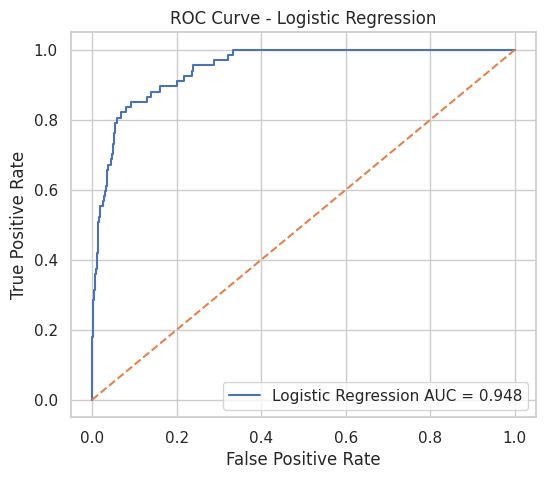

In [38]:
y_pred_logistic = logistic_model.predict(X_test_scaled)

# Predicted probabilities for ROC-AUC
y_prob_logistic = logistic_model.predict_proba(X_test_scaled)[:, 1]

# Evaluation metrics
logistic_accuracy = accuracy_score(y_test, y_pred_logistic)
logistic_auc = roc_auc_score(y_test, y_prob_logistic)
logistic_cm = confusion_matrix(y_test, y_pred_logistic)

print("LOGISTIC REGRESSION RESULTS")
print("Accuracy:", round(logistic_accuracy, 3))
print("ROC-AUC:", round(logistic_auc, 3))

print("\nConfusion Matrix:")
print(logistic_cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_logistic, zero_division=0))

fpr_logistic, tpr_logistic, thresholds_logistic = roc_curve(y_test, y_prob_logistic)

plt.figure(figsize=(6, 5))
plt.plot(fpr_logistic, tpr_logistic, label=f"Logistic Regression AUC = {logistic_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

Again the response variable is binary so it just predicts the probability that a customer will default (1) or not (0). Accuracy shows the overall proportion of correct predictions while the confusion matrix shows the number of correct and incorrect classifications for both default and non-default customers. 

ROC-AUC measures how well the model separates customers who default from those who do not.

The coefficients show the direction and strength of each predictor. A positive coefficient means that the predictor increases the probability of default, while a negative coefficient means that the predictor decreases the probability of default.

For this dataset, balance is usually expected to be one of the strongest predictors because customers with higher credit card balances are more likely to default.


## III. Neural Network Model (12 points)
### A. Neural Network Architecture (5 points)

In [40]:
neural_network_model = Sequential()

# Input layer and one hidden layer with 10 hidden units
neural_network_model.add(Dense(
    units=10,
    activation="relu",
    input_shape=(X_train_scaled.shape[1],)
))

# Dropout regularization
neural_network_model.add(Dropout(rate=0.30))

# Output layer
neural_network_model.add(Dense(
    units=1,
    activation="sigmoid"
))

# Compile model
neural_network_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Display model summary
neural_network_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 10)             │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51 (204.00 B)

 Trainable params: 51 (204.00 B)

 Non-trainable params: 0 (0.00 B)

The hidden layer uses the ReLU activation function. ReLU stands for Rectified Linear Unit. It allows the neural network to learn nonlinear patterns by outputting positive values directly and setting negative values to zero.

The output layer uses the sigmoid activation function because the task is binary classification. The sigmoid function outputs a value between 0 and 1, which can be interpreted as the predicted probability of default.

Dropout regularization was added to reduce overfitting. During training, dropout randomly ignores some hidden units. This prevents the neural network from relying too heavily on specific neurons and helps improve generalization to new data.

### B. Model Training and Evaluation (7 points)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8186 - loss: 0.4741 - val_accuracy: 0.9663 - val_loss: 0.2783
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9646 - loss: 0.2734 - val_accuracy: 0.9663 - val_loss: 0.1706
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9659 - loss: 0.1919 - val_accuracy: 0.9663 - val_loss: 0.1283
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9659 - loss: 0.1567 - val_accuracy: 0.9663 - val_loss: 0.1093
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9671 - loss: 0.1282 - val_accuracy: 0.9663 - val_loss: 0.0995
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9669 - loss: 0.1194 - val_accuracy: 0.9663 - val_loss: 0.0933
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9672 - loss: 0.1093 - val_accuracy: 0.9663 - val_loss: 0.0890
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9663 - loss: 0.1071 - val_accu

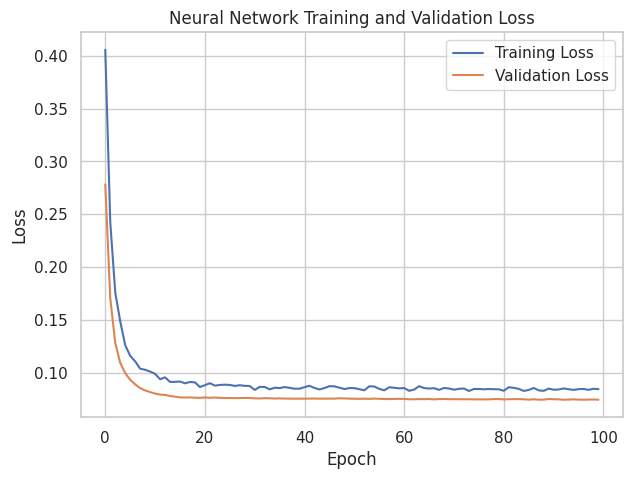

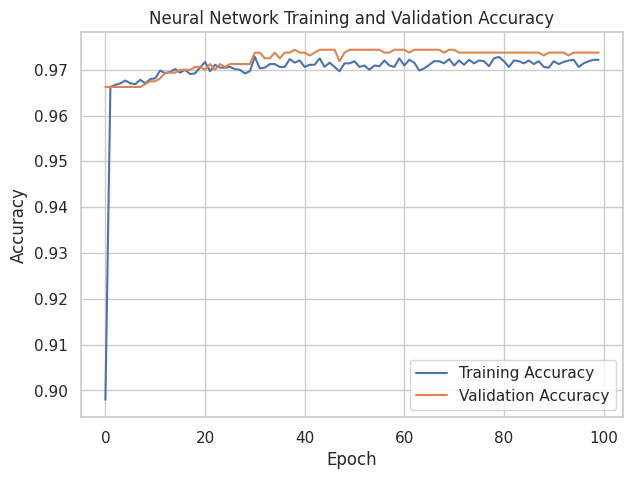

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
NEURAL NETWORK RESULTS
Accuracy: 0.973
ROC-AUC: 0.947

Confusion Matrix:
[[1925    8]
 [  47   20]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1933
           1       0.71      0.30      0.42        67

    accuracy                           0.97      2000
   macro avg       0.85      0.65      0.70      2000
weighted avg       0.97      0.97      0.97      2000



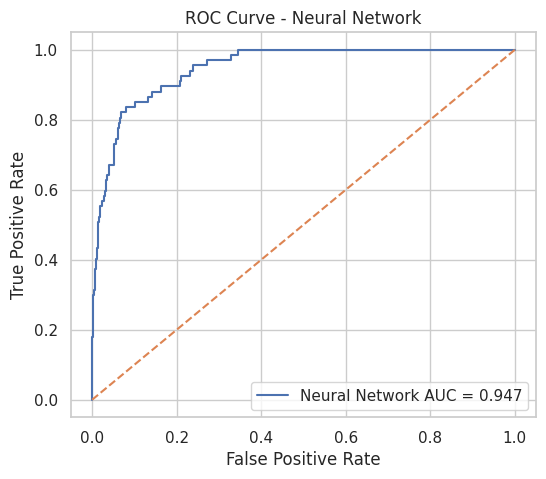

In [41]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = neural_network_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.20,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

plt.figure(figsize=(7, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Neural Network Training and Validation Loss")
plt.legend()
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Neural Network Training and Validation Accuracy")
plt.legend()
plt.show()

# Predicted probabilities
y_prob_nn = neural_network_model.predict(X_test_scaled).ravel()

# Convert probabilities to class predictions using 0.5 threshold
y_pred_nn = (y_prob_nn >= 0.5).astype(int)

# Evaluation metrics
nn_accuracy = accuracy_score(y_test, y_pred_nn)
nn_auc = roc_auc_score(y_test, y_prob_nn)
nn_cm = confusion_matrix(y_test, y_pred_nn)

print("NEURAL NETWORK RESULTS")
print("Accuracy:", round(nn_accuracy, 3))
print("ROC-AUC:", round(nn_auc, 3))

print("\nConfusion Matrix:")
print(nn_cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nn, zero_division=0))

fpr_nn, tpr_nn, thresholds_nn = roc_curve(y_test, y_prob_nn)

plt.figure(figsize=(6, 5))
plt.plot(fpr_nn, tpr_nn, label=f"Neural Network AUC = {nn_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Neural Network")
plt.legend()
plt.show()

Based on the training results, the neural network does not show strong evidence of overfitting. The training accuracy and validation accuracy are relatively close, meaning the model performs similarly on both the training data and validation data. This suggests that the model was able to learn useful patterns without memorizing the training data too much.

The use of dropout regularization helped control overfitting by randomly dropping some hidden units during training. This forced the model to learn more general patterns rather than relying too heavily on specific neurons.

## IV. Comparative Analysis and Interpretation (8 points)

,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.973,0.948
1,Neural Network,0.972,0.947


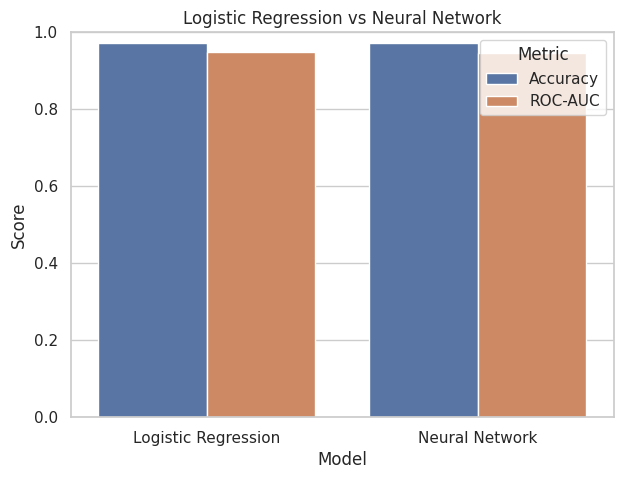

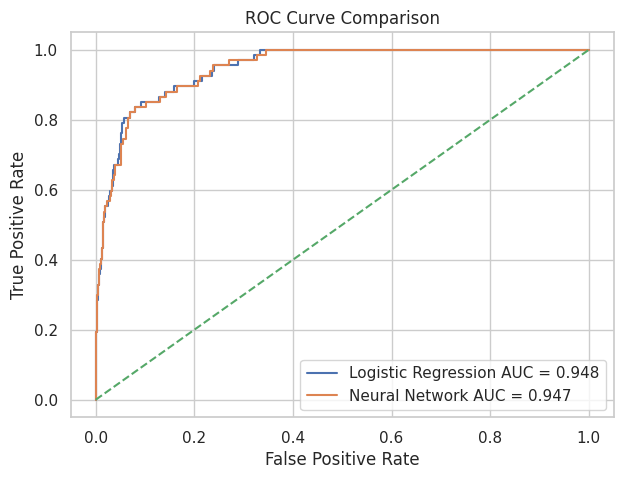

In [42]:
comparison_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Neural Network"],
    "Accuracy": [logistic_accuracy, nn_accuracy],
    "ROC-AUC": [logistic_auc, nn_auc]
})

comparison_results["Accuracy"] = comparison_results["Accuracy"].round(3)
comparison_results["ROC-AUC"] = comparison_results["ROC-AUC"].round(3)

display(comparison_results)

comparison_melted = comparison_results.melt(
    id_vars="Model",
    value_vars=["Accuracy", "ROC-AUC"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(7, 5))
sns.barplot(data=comparison_melted, x="Model", y="Score", hue="Metric")
plt.title("Logistic Regression vs Neural Network")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(fpr_logistic, tpr_logistic, label=f"Logistic Regression AUC = {logistic_auc:.3f}")
plt.plot(fpr_nn, tpr_nn, label=f"Neural Network AUC = {nn_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

#### Best Model

The better model is Logistic Regression based on its higher ROC-AUC but it's negligible since the difference is only 0.001 and accuracy could be misleading because the dataset is likely imbalanced anyway. Logistic Regression may be higher because it is simpler and easier to interpret, as seen intuitively with its few variables. 
Logistic regression is fast and easy to interpret compared to Neural Network but it assumes a simple linear relationship. Neural Network is more flexible since
it can learn nonlinear relationships between predictors and response variables but it is less interpretable compared to Logistic Regression.


#### Effect of Dropout Regularization

Dropout regularization reduces overfitting by randomly ignoring a percentage of hidden units during training. In this model, a dropout rate of 0.30 was used, meaning 30% of the hidden units were randomly dropped during each training update.
This forces the model to avoid relying too much on specific neurons. As a result, the model can generalize better to new data.
However, too much dropout can lead to underfitting because the model may lose too much information during training. Therefore, dropout must be balanced carefully.

#### Model Interpretability vs Predictive Performance

Logistic Regression is more interpretable because its coefficients directly show the effect of each predictor on default probability. This makes it useful for explaining financial risk decisions.
The Neural Network may provide stronger predictive performance if the data contains nonlinear relationships. However, it is less interpretable because the prediction comes from hidden-layer computations.
In real-world credit risk analysis, interpretability is very important. Therefore, if both models perform similarly, Logistic Regression may be preferred. If the Neural Network performs much better, it may be useful for prediction, but additional explanation methods may be needed.